In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
from groq import Groq
import os

In [2]:
load_dotenv()
api_key = os.getenv("GROQ_API_KEY")

In [3]:
client = Groq(api_key=api_key)
def call_llm(prompt):
    completion = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    return completion.choices[0].message.content


# response = call_llm("What is LangGraph?")
# print(response)

In [4]:
class BlogState(TypedDict):

    title : str
    outline : str
    content : str

In [5]:
def create_outline(state: BlogState) -> BlogState:

    # fecth title
    title = state["title"]

    # call llm
    prompt = f"Generate a detailed outline for a blog on the topic {title}"
    outline = call_llm(prompt=prompt)

    #update state
    state["outline"] = outline

    return state

In [6]:
def create_blog(state: BlogState)-> BlogState:

    # fetch title and outline 
    title = state["title"]
    outline = state["outline"]

    prompt = f"write a detailed blog on the title {title} using the following outline \n {outline}"

    content = call_llm(prompt=prompt)

    state["content"] = content

    return state

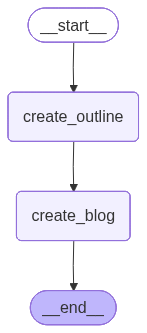

In [8]:
graph = StateGraph(BlogState)

# nodes
graph.add_node("create_outline", create_outline)
graph.add_node("create_blog", create_blog)

# edges
graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_blog")
graph.add_edge("create_blog", END)

workflow = graph.compile()
workflow

In [9]:
initial_state = {"title" : "Rise of AI in India"}
final_state = workflow.invoke(initial_state)

In [10]:
final_state

{'title': 'Rise of AI in India',
 'outline': 'Here\'s a detailed outline for a blog on the topic "Rise of AI in India":\n\n**I. Introduction**\n\n* Brief overview of Artificial Intelligence (AI) and its growing importance globally\n* Introduction to the Indian context: why India is an exciting market for AI\n* Thesis statement: India is poised to become a major player in the global AI landscape, with significant investments, innovations, and applications across various sectors.\n\n**II. Current State of AI in India**\n\n* Overview of the current AI ecosystem in India: startups, research institutions, government initiatives\n* Key statistics:\n\t+ Number of AI startups in India\n\t+ Funding received by AI startups in India\n\t+ Growth rate of AI industry in India\n* Notable Indian AI companies and their achievements\n\n**III. Drivers of AI Adoption in India**\n\n* Government initiatives:\n\t+ National AI Mission\n\t+ AI task force\n\t+ Funding for AI research and development\n* Private 

In [12]:
print(final_state["outline"])

Here's a detailed outline for a blog on the topic "Rise of AI in India":

**I. Introduction**

* Brief overview of Artificial Intelligence (AI) and its growing importance globally
* Introduction to the Indian context: why India is an exciting market for AI
* Thesis statement: India is poised to become a major player in the global AI landscape, with significant investments, innovations, and applications across various sectors.

**II. Current State of AI in India**

* Overview of the current AI ecosystem in India: startups, research institutions, government initiatives
* Key statistics:
	+ Number of AI startups in India
	+ Funding received by AI startups in India
	+ Growth rate of AI industry in India
* Notable Indian AI companies and their achievements

**III. Drivers of AI Adoption in India**

* Government initiatives:
	+ National AI Mission
	+ AI task force
	+ Funding for AI research and development
* Private sector investments:
	+ Venture capital funding for AI startups
	+ Corporate 

In [13]:
print(final_state["content"])

**The Rise of AI in India: A New Era of Innovation and Growth**

**Introduction**

Artificial Intelligence (AI) has been transforming the world at an unprecedented pace, and its importance is growing exponentially. From virtual assistants to self-driving cars, AI has been making its presence felt across various sectors. India, with its vast population, growing economy, and increasing digital literacy, is an exciting market for AI. With significant investments, innovations, and applications across various sectors, India is poised to become a major player in the global AI landscape.

**Current State of AI in India**

The current AI ecosystem in India is thriving, with over 400 AI startups, research institutions, and government initiatives driving growth. The Indian AI industry has received significant funding, with investments reaching $150 million in 2020, and is expected to grow at a CAGR of 30% in the next five years. Notable Indian AI companies, such as Infosys, Wipro, and Tata Consu